# Aula 04 - Exercício Prático: Representação Vetorial de Texto

**Curso:** Processamento de Linguagem Natural  
**Aluno:** Gisele Fonseca  
**Data:** 21/01/2026

## Instruções
1. Complete todos os exercícios marcados com `# === SEU CÓDIGO AQUI ===`
2. Execute as células de teste para verificar suas respostas
3. **Não modifique as células de teste**
4.  Execute todas as células em ordem
5.  Respostas devem ser armazenadas nas variáveis indicadas

## Critérios de Avaliação
- **Conteúdo (100%):** Testes automáticos

---

## Dataset

Utilizaremos o dataset **B2W-Reviews01** para treinar modelos de linguagem.

---

---

## Setup do Ambiente

Execute as células abaixo para configurar o ambiente de correção.

In [1]:
# === CONFIGURAÇÃO INICIAL ===

!pip install --upgrade pip --quiet
!pip cache purge
!pip install otter-grader --no-cache-dir -q
!pip install nltk --quiet
!mkdir -p tests

print("Ambiente configurado!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.7 MB/s eta 0:00:00
Files removed: 6 (1.8 MB)
Ambiente configurado!


In [2]:
# Criar diretório de testes
import os
os.makedirs('tests', exist_ok=True)

In [3]:
%%writefile tests/q1.py
OK_FORMAT = True
test = {
    "name": "q1",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(preprocessar_texto_bow)
True
"""
                },
                {
                    "code": r"""
>>> resultado = preprocessar_texto_bow("O Produto é BOM!")
>>> isinstance(resultado, list)
True
"""
                },
                {
                    "code": r"""
>>> resultado = preprocessar_texto_bow("TESTE 123 exemplo")
>>> all(t.islower() for t in resultado)
True
"""
                },
                {
                    "code": r"""
>>> resultado = preprocessar_texto_bow("Preço: R$99,90! Ótimo.")
>>> all(t.isalpha() for t in resultado)
True
"""
                },
                {
                    "code": r"""
>>> resultado = preprocessar_texto_bow("bom bom bom")
>>> resultado.count("bom") == 3
True
"""
                },
                {
                    "code": r"""
>>> preprocessar_texto_bow("")
[]
"""
                },
                {
                    "code": r"""
>>> preprocessar_texto_bow(123) == []
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q1.py


In [4]:
%%writefile tests/q2.py
OK_FORMAT = True
test = {
    "name": "q2",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'vocabulario_manual' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'matriz_bow_manual' in dir()
True
"""
                },
                {
                    "code": r"""
>>> isinstance(vocabulario_manual, list)
True
"""
                },
                {
                    "code": r"""
>>> vocabulario_manual == sorted(vocabulario_manual)
True
"""
                },
                {
                    "code": r"""
>>> len(vocabulario_manual) == len(set(vocabulario_manual))
True
"""
                },
                {
                    "code": r"""
>>> isinstance(matriz_bow_manual, list)
True
"""
                },
                {
                    "code": r"""
>>> len(matriz_bow_manual) == 3
True
"""
                },
                {
                    "code": r"""
>>> all(len(v) == len(vocabulario_manual) for v in matriz_bow_manual)
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(x, int) for v in matriz_bow_manual for x in v)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q2.py


In [5]:
%%writefile tests/q3.py
OK_FORMAT = True
test = {
    "name": "q3",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'vetorizador_count' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'matriz_count_treino' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'matriz_count_teste' in dir()
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import CountVectorizer
>>> isinstance(vetorizador_count, CountVectorizer)
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_count.max_features == 3000
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_count.ngram_range == (1, 2)
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_count.min_df == 2
True
"""
                },
                {
                    "code": r"""
>>> from scipy.sparse import issparse
>>> issparse(matriz_count_treino)
True
"""
                },
                {
                    "code": r"""
>>> matriz_count_treino.shape[0] == len(reviews_treino)
True
"""
                },
                {
                    "code": r"""
>>> matriz_count_teste.shape[1] == matriz_count_treino.shape[1]
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q3.py


In [6]:
%%writefile tests/q4.py
OK_FORMAT = True
test = {
    "name": "q4",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'vetorizador_tfidf' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'matriz_tfidf_treino' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'matriz_tfidf_teste' in dir()
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> isinstance(vetorizador_tfidf, TfidfVectorizer)
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_tfidf.max_features == 3000
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_tfidf.ngram_range == (1, 2)
True
"""
                },
                {
                    "code": r"""
>>> vetorizador_tfidf.min_df == 2
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> normas = np.sqrt((matriz_tfidf_treino.toarray() ** 2).sum(axis=1))
>>> np.allclose(normas[normas > 0], 1.0, atol=0.01)
True
"""
                },
                {
                    "code": r"""
>>> matriz_tfidf_treino.shape[0] == len(reviews_treino)
True
"""
                },
                {
                    "code": r"""
>>> matriz_tfidf_teste.shape[1] == matriz_tfidf_treino.shape[1]
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q4.py


In [7]:
%%writefile tests/q5.py
OK_FORMAT = True
test = {
    "name": "q5",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(calcular_similaridade_documentos)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto bom", "produto ruim", "entrega rápida"]
>>> vec_t = TfidfVectorizer()
>>> mat_t = vec_t.fit_transform(docs_t)
>>> sim = calcular_similaridade_documentos(mat_t)
>>> isinstance(sim, np.ndarray)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto bom", "produto ruim", "entrega rápida"]
>>> vec_t = TfidfVectorizer()
>>> mat_t = vec_t.fit_transform(docs_t)
>>> sim = calcular_similaridade_documentos(mat_t)
>>> sim.shape == (3, 3)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto bom", "produto ruim", "entrega rápida"]
>>> vec_t = TfidfVectorizer()
>>> mat_t = vec_t.fit_transform(docs_t)
>>> sim = calcular_similaridade_documentos(mat_t)
>>> np.allclose(np.diag(sim), 1.0)
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto bom", "produto ruim", "entrega rápida"]
>>> vec_t = TfidfVectorizer()
>>> mat_t = vec_t.fit_transform(docs_t)
>>> sim = calcular_similaridade_documentos(mat_t)
>>> bool(((sim >= -1e-9) & (sim <= 1 + 1e-9)).all())
True
"""
                },
                {
                    "code": r"""
>>> import numpy as np
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto bom", "produto ruim", "entrega rápida"]
>>> vec_t = TfidfVectorizer()
>>> mat_t = vec_t.fit_transform(docs_t)
>>> sim = calcular_similaridade_documentos(mat_t)
>>> np.allclose(sim, sim.T)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q5.py


In [8]:
%%writefile tests/q6.py
OK_FORMAT = True
test = {
    "name": "q6",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> callable(buscar_documentos_similares)
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto excelente", "produto ruim", "entrega rápida bom"]
>>> vec_t = TfidfVectorizer()
>>> vec_t.fit(docs_t)
TfidfVectorizer()
>>> resultado = buscar_documentos_similares("produto bom", docs_t, vec_t, top_n=2)
>>> isinstance(resultado, list)
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto excelente", "produto ruim", "entrega rápida bom"]
>>> vec_t = TfidfVectorizer()
>>> vec_t.fit(docs_t)
TfidfVectorizer()
>>> resultado = buscar_documentos_similares("produto bom", docs_t, vec_t, top_n=2)
>>> len(resultado) == 2
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto excelente", "produto ruim", "entrega rápida bom"]
>>> vec_t = TfidfVectorizer()
>>> vec_t.fit(docs_t)
TfidfVectorizer()
>>> resultado = buscar_documentos_similares("produto bom", docs_t, vec_t, top_n=2)
>>> all(isinstance(item, tuple) and len(item) == 2 for item in resultado)
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto excelente", "produto ruim", "entrega rápida bom"]
>>> vec_t = TfidfVectorizer()
>>> vec_t.fit(docs_t)
TfidfVectorizer()
>>> resultado = buscar_documentos_similares("produto bom", docs_t, vec_t, top_n=2)
>>> all(isinstance(item[0], str) and isinstance(item[1], float) for item in resultado)
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> docs_t = ["produto excelente", "produto ruim", "entrega rápida bom"]
>>> vec_t = TfidfVectorizer()
>>> vec_t.fit(docs_t)
TfidfVectorizer()
>>> resultado = buscar_documentos_similares("produto bom", docs_t, vec_t, top_n=2)
>>> scores = [item[1] for item in resultado]
>>> scores == sorted(scores, reverse=True)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q6.py


In [9]:
%%writefile tests/q7.py
OK_FORMAT = True
test = {
    "name": "q7",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'pipeline_classificacao' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'acuracia_teste' in dir()
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.pipeline import Pipeline
>>> isinstance(pipeline_classificacao, Pipeline)
True
"""
                },
                {
                    "code": r"""
>>> 'tfidf' in pipeline_classificacao.named_steps
True
"""
                },
                {
                    "code": r"""
>>> 'classificador' in pipeline_classificacao.named_steps
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.feature_extraction.text import TfidfVectorizer
>>> isinstance(pipeline_classificacao.named_steps['tfidf'], TfidfVectorizer)
True
"""
                },
                {
                    "code": r"""
>>> from sklearn.linear_model import LogisticRegression
>>> isinstance(pipeline_classificacao.named_steps['classificador'], LogisticRegression)
True
"""
                },
                {
                    "code": r"""
>>> isinstance(acuracia_teste, float)
True
"""
                },
                {
                    "code": r"""
>>> 0.0 <= acuracia_teste <= 1.0
True
"""
                },
                {
                    "code": r"""
>>> acuracia_teste >= 0.70
True
"""
                },
                {
                    "code": r"""
>>> predicao = pipeline_classificacao.predict(["produto excelente recomendo"])
>>> len(predicao) == 1
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q7.py


In [10]:
%%writefile tests/q8.py
OK_FORMAT = True
test = {
    "name": "q8",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
>>> 'palavras_positivas' in dir()
True
"""
                },
                {
                    "code": r"""
>>> 'palavras_negativas' in dir()
True
"""
                },
                {
                    "code": r"""
>>> isinstance(palavras_positivas, list)
True
"""
                },
                {
                    "code": r"""
>>> isinstance(palavras_negativas, list)
True
"""
                },
                {
                    "code": r"""
>>> len(palavras_positivas) == 10
True
"""
                },
                {
                    "code": r"""
>>> len(palavras_negativas) == 10
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(item, tuple) and len(item) == 2 for item in palavras_positivas)
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(item, tuple) and len(item) == 2 for item in palavras_negativas)
True
"""
                },
                {
                    "code": r"""
>>> all(isinstance(p[0], str) and isinstance(p[1], (int, float)) for p in palavras_positivas)
True
"""
                },
                {
                    "code": r"""
>>> coefs_pos = [p[1] for p in palavras_positivas]
>>> coefs_pos == sorted(coefs_pos, reverse=True)
True
"""
                },
                {
                    "code": r"""
>>> coefs_neg = [p[1] for p in palavras_negativas]
>>> coefs_neg == sorted(coefs_neg)
True
"""
                },
                {
                    "code": r"""
>>> all(p[1] > 0 for p in palavras_positivas)
True
"""
                },
                {
                    "code": r"""
>>> all(p[1] < 0 for p in palavras_negativas)
True
"""
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q8.py


---

## Imports e Configuração

In [13]:
# @title
# Imports e configurações
import otter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import nltk
from nltk.corpus import stopwords
import random # Adicionar esta linha

nltk.download('stopwords', quiet=True)

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Stopwords em português
STOPWORDS_PT = stopwords.words('portuguese')

# Seed para reprodutibilidade
random.seed(42)
np.random.seed(42)

# Inicializar grader
grader = otter.Notebook()

print("Setup completo!")

Setup completo!


---

## Carregamento dos Dados

In [14]:
# Carregar dataset B2W-Reviews (NÃO MODIFIQUE)
URL_DATASET = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

df = pd.read_csv(URL_DATASET, nrows=3000)
df = df.dropna(subset=['review_text'])

# Criar labels de sentimento (1=positivo, 0=negativo)
df_sentimento = df[df['overall_rating'] != 3].copy()
df_sentimento['label'] = (df_sentimento['overall_rating'] >= 4).astype(int)

print(f"Dataset carregado: {len(df)} reviews")
print(f"Dataset para classificação: {len(df_sentimento)} reviews")
print(f"  Positivos: {df_sentimento['label'].sum()}")
print(f"  Negativos: {len(df_sentimento) - df_sentimento['label'].sum()}")

Dataset carregado: 2895 reviews
Dataset para classificação: 2550 reviews
  Positivos: 1795
  Negativos: 755


In [15]:
# Dividir dados para exercícios (NÃO MODIFIQUE)

# Amostra para exercícios de vetorização
reviews_amostra = df['review_text'].head(500).tolist()

# Dados para classificação
X_textos = df_sentimento['review_text'].values
y_labels = df_sentimento['label'].values

# Split treino/teste com seed fixo
reviews_treino, reviews_teste, labels_treino, labels_teste = train_test_split(
    X_textos, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print(f"Amostra para vetorização: {len(reviews_amostra)} reviews")
print(f"Treino: {len(reviews_treino)} | Teste: {len(reviews_teste)}")

Amostra para vetorização: 500 reviews
Treino: 2040 | Teste: 510


---

## Questão 1: Pré-processamento para Bag of Words

Implemente a função `preprocessar_texto_bow` que prepara um texto para representação Bag of Words.

**Requisitos da função:**
1. Receber uma string como entrada
2. Converter para minúsculas
3. Tokenizar usando split (separar por espaços)
4. Remover tokens que **não são puramente alfabéticos** (use `isalpha()`)
5. Retornar lista de tokens
6. Se a entrada não for string, retornar lista vazia

**Assinatura:** `preprocessar_texto_bow(texto: str) -> list`

In [16]:
def preprocessar_texto_bow(texto):
    """
    Pré-processa texto para Bag of Words.

    Parâmetros:
        texto: String a ser processada

    Retorna:
        list: Lista de tokens em minúsculas, apenas alfabéticos
    """
    # SUA RESPOSTA AQUI
    if not isinstance(texto, str):
        return []
    tokens = texto.lower().split()
    tokens = [t for t in tokens if t.isalpha()]
    return tokens


In [17]:
# Testar sua implementação
teste_q1 = preprocessar_texto_bow("O Produto é ÓTIMO! Nota 10!!!")
print(f"Entrada: 'O Produto é ÓTIMO! Nota 10!!!'")
print(f"Saída: {teste_q1}")

Entrada: 'O Produto é ÓTIMO! Nota 10!!!'
Saída: ['o', 'produto', 'é', 'nota']


In [18]:
grader.check("q1")

q1 results: All test cases passed!

---

## Questão 2: Construção Manual de Bag of Words

Usando a função `preprocessar_texto_bow` da questão anterior, construa manualmente uma representação Bag of Words para os seguintes documentos:

```python
documentos_q2 = [
    "O produto é excelente muito bom",
    "Produto ruim não gostei",
    "Entrega rápida produto chegou bom"
]
```

**Você deve criar:**
1. `vocabulario_manual`: Lista com todas as palavras únicas, **ordenada alfabeticamente**
2. `matriz_bow_manual`: Lista de listas, onde cada sublista é o vetor de contagens de um documento

**Requisitos:**
- Use sua função `preprocessar_texto_bow` para processar cada documento
- O vocabulário deve conter apenas palavras únicas e estar ordenado
- Cada vetor deve ter o mesmo tamanho do vocabulário
- Os valores devem ser inteiros representando contagens

In [19]:
# Documentos para esta questão (NÃO MODIFIQUE)
documentos_q2 = [
    "O produto é excelente muito bom",
    "Produto ruim não gostei",
    "Entrega rápida produto chegou bom"
]

# SUA RESPOSTA AQUI
tokens_docs = [preprocessar_texto_bow(doc) for doc in documentos_q2]

vocabulario_manual = sorted(list(set([token for doc in tokens_docs for token in doc])))

matriz_bow_manual = []
for doc in tokens_docs:
    vetor = [doc.count(palavra) for palavra in vocabulario_manual]
    matriz_bow_manual.append(vetor)

In [20]:
# Visualizar resultado
print(f"Vocabulário ({len(vocabulario_manual)} palavras): {vocabulario_manual}")
print(f"\nMatriz BoW:")
df_q2 = pd.DataFrame(matriz_bow_manual, columns=vocabulario_manual)
df_q2.index = [f'Doc {i+1}' for i in range(len(documentos_q2))]
print(df_q2)

Vocabulário (12 palavras): ['bom', 'chegou', 'entrega', 'excelente', 'gostei', 'muito', 'não', 'o', 'produto', 'ruim', 'rápida', 'é']

Matriz BoW:
       bom  chegou  entrega  excelente  gostei  muito  não  o  produto  ruim  \
Doc 1    1       0        0          1       0      1    0  1        1     0   
Doc 2    0       0        0          0       1      0    1  0        1     1   
Doc 3    1       1        1          0       0      0    0  0        1     0   

       rápida  é  
Doc 1       0  1  
Doc 2       0  0  
Doc 3       1  0  


In [21]:
grader.check("q2")

q2 results: All test cases passed!

---

## Questão 3: CountVectorizer com Configurações Específicas

Crie um `CountVectorizer` com as seguintes configurações **exatas**:
- `max_features=3000`
- `ngram_range=(1, 2)` (unigramas e bigramas)
- `min_df=2`
- `stop_words=STOPWORDS_PT` (variável já definida)

**Você deve criar:**
1. `vetorizador_count`: O CountVectorizer configurado
2. `matriz_count_treino`: Matriz resultante de `fit_transform` nos dados de **treino** (`reviews_treino`)
3. `matriz_count_teste`: Matriz resultante de `transform` nos dados de **teste** (`reviews_teste`)

**IMPORTANTE:** Use `fit_transform` apenas no treino e `transform` no teste!

In [22]:
# SUA RESPOSTA AQUI
vetorizador_count = CountVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words=STOPWORDS_PT
)

matriz_count_treino = vetorizador_count.fit_transform(reviews_treino)
matriz_count_teste = vetorizador_count.transform(reviews_teste)

In [23]:
# Visualizar resultado
print(f"Configuração do vetorizador:")
print(f"  max_features: {vetorizador_count.max_features}")
print(f"  ngram_range: {vetorizador_count.ngram_range}")
print(f"  min_df: {vetorizador_count.min_df}")
print(f"\nMatriz treino: {matriz_count_treino.shape}")
print(f"Matriz teste: {matriz_count_teste.shape}")
print(f"\nExemplos de features: {vetorizador_count.get_feature_names_out()[:10]}")

Configuração do vetorizador:
  max_features: 3000
  ngram_range: (1, 2)
  min_df: 2

Matriz treino: (2040, 3000)
Matriz teste: (510, 3000)

Exemplos de features: ['00' '01' '01 01' '01 12' '01 18' '01 2018' '01 chegou' '02' '02 01' '03']


In [24]:
grader.check("q3")

q3 results: All test cases passed!

---

## Questão 4: TfidfVectorizer com Configurações Específicas

Crie um `TfidfVectorizer` com as seguintes configurações **exatas**:
- `max_features=3000`
- `ngram_range=(1, 2)` (unigramas e bigramas)
- `min_df=2`
- `stop_words=STOPWORDS_PT`

**Você deve criar:**
1. `vetorizador_tfidf`: O TfidfVectorizer configurado
2. `matriz_tfidf_treino`: Matriz resultante de `fit_transform` nos dados de **treino** (`reviews_treino`)
3. `matriz_tfidf_teste`: Matriz resultante de `transform` nos dados de **teste** (`reviews_teste`)

**IMPORTANTE:** Use `fit_transform` apenas no treino e `transform` no teste!

In [25]:
# SUA RESPOSTA AQUI
vetorizador_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words=STOPWORDS_PT
)

matriz_tfidf_treino = vetorizador_tfidf.fit_transform(reviews_treino)
matriz_tfidf_teste = vetorizador_tfidf.transform(reviews_teste)

In [26]:
# Visualizar resultado
print(f"Configuração do vetorizador TF-IDF:")
print(f"  max_features: {vetorizador_tfidf.max_features}")
print(f"  ngram_range: {vetorizador_tfidf.ngram_range}")
print(f"  min_df: {vetorizador_tfidf.min_df}")
print(f"\nMatriz treino: {matriz_tfidf_treino.shape}")
print(f"Matriz teste: {matriz_tfidf_teste.shape}")

# Verificar normalização
normas = np.sqrt((matriz_tfidf_treino.toarray() ** 2).sum(axis=1))
print(f"\nNorma dos vetores (devem ser ~1.0): {normas[:5].round(3)}")

Configuração do vetorizador TF-IDF:
  max_features: 3000
  ngram_range: (1, 2)
  min_df: 2

Matriz treino: (2040, 3000)
Matriz teste: (510, 3000)

Norma dos vetores (devem ser ~1.0): [1. 1. 1. 1. 1.]


In [27]:
grader.check("q4")

q4 results: All test cases passed!

---

## Questão 5: Calcular Similaridade do Cosseno

Implemente a função `calcular_similaridade_documentos` que calcula a matriz de similaridade do cosseno entre todos os documentos.

**Requisitos da função:**
1. Receber uma matriz TF-IDF (esparsa ou densa)
2. Usar `cosine_similarity` do sklearn
3. Retornar uma matriz numpy onde `matriz[i][j]` é a similaridade entre doc i e doc j

**Assinatura:** `calcular_similaridade_documentos(matriz_tfidf) -> np.ndarray`

**Propriedades esperadas:**
- Diagonal deve ser 1.0 (documento consigo mesmo)
- Valores entre 0 e 1
- Matriz simétrica

In [28]:
def calcular_similaridade_documentos(matriz_tfidf):
    """
    Calcula matriz de similaridade do cosseno entre documentos.

    Parâmetros:
        matriz_tfidf: Matriz TF-IDF (sparse ou densa)

    Retorna:
        np.ndarray: Matriz de similaridade (n_docs x n_docs)
    """
    # SUA RESPOSTA AQUI

    return cosine_similarity(matriz_tfidf)


In [29]:
# Testar com amostra pequena
docs_q5 = ["produto bom excelente", "produto ruim péssimo", "entrega rápida chegou"]
tfidf_q5 = TfidfVectorizer()
X_q5 = tfidf_q5.fit_transform(docs_q5)

sim_q5 = calcular_similaridade_documentos(X_q5)
print("Matriz de Similaridade:")
print(pd.DataFrame(sim_q5.round(2),
                   index=['Doc 1', 'Doc 2', 'Doc 3'],
                   columns=['Doc 1', 'Doc 2', 'Doc 3']))

Matriz de Similaridade:
       Doc 1  Doc 2  Doc 3
Doc 1   1.00   0.22    0.0
Doc 2   0.22   1.00    0.0
Doc 3   0.00   0.00    1.0


In [30]:
grader.check("q5")

q5 results: All test cases passed!

---

## Questão 6: Sistema de Busca de Documentos

Implemente a função `buscar_documentos_similares` que encontra os documentos mais similares a uma query.

**Requisitos da função:**
1. Receber: query (string), lista de documentos, vetorizador treinado, e top_n
2. Vetorizar a query usando `transform` (não fit_transform!)
3. Vetorizar os documentos usando `transform`
4. Calcular similaridade do cosseno entre query e cada documento
5. Retornar os top_n documentos mais similares

**Assinatura:** `buscar_documentos_similares(query, documentos, vectorizer, top_n=3) -> list`

**Formato de retorno:** Lista de tuplas `[(documento, similaridade), ...]` ordenada por similaridade decrescente

In [31]:
def buscar_documentos_similares(query, documentos, vectorizer, top_n=3):
    """
    Busca documentos mais similares a uma query.

    Parâmetros:
        query (str): Texto de busca
        documentos (list): Lista de documentos para buscar
        vectorizer: Vetorizador TF-IDF já treinado (fitted)
        top_n (int): Número de resultados a retornar

    Retorna:
        list: Lista de tuplas (documento, similaridade) ordenada por similaridade
    """
    # SUA RESPOSTA AQUI

    query_vec = vectorizer.transform([query])
    docs_vec = vectorizer.transform(documentos)

    similaridades = cosine_similarity(query_vec, docs_vec)[0]

    resultados = list(zip(documentos, similaridades))
    resultados = sorted(resultados, key=lambda x: x[1], reverse=True)

    return resultados[:top_n]

In [32]:
# Testar busca
docs_busca = [
    "Produto de excelente qualidade, muito bom",
    "Péssima qualidade, não recomendo",
    "Entrega rápida, produto conforme anunciado",
    "Chegou com defeito, precisei devolver",
    "Superou expectativas, recomendo muito"
]

# Treinar vetorizador
vec_busca = TfidfVectorizer()
vec_busca.fit(docs_busca)

# Buscar
query_teste = "produto bom recomendo"
resultados_q6 = buscar_documentos_similares(query_teste, docs_busca, vec_busca, top_n=3)

print(f"Query: '{query_teste}'")
print(f"\nResultados:")
for doc, sim in resultados_q6:
    print(f"  [{sim:.3f}] {doc}")

Query: 'produto bom recomendo'

Resultados:
  [0.489] Produto de excelente qualidade, muito bom
  [0.236] Péssima qualidade, não recomendo
  [0.236] Superou expectativas, recomendo muito


In [33]:
grader.check("q6")

q6 results: All test cases passed!

---

## Questão 7: Pipeline de Classificação de Sentimentos

Crie um Pipeline do scikit-learn para classificação de sentimentos.

**O pipeline deve conter:**
1. **Primeiro passo** (nome: `'tfidf'`): TfidfVectorizer com:
   - `max_features=5000`
   - `ngram_range=(1, 2)`
   - `stop_words=STOPWORDS_PT`
   
2. **Segundo passo** (nome: `'classificador'`): LogisticRegression com:
   - `max_iter=1000`
   - `random_state=42`

**Você deve criar:**
1. `pipeline_classificacao`: O Pipeline configurado e **treinado** nos dados de treino
2. `acuracia_teste`: Acurácia do modelo nos dados de teste (float entre 0 e 1)

**Use os dados:** `reviews_treino`, `labels_treino`, `reviews_teste`, `labels_teste`

In [34]:
# SUA RESPOSTA AQUI
pipeline_classificacao = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=STOPWORDS_PT
    )),
    ('classificador', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipeline_classificacao.fit(reviews_treino, labels_treino)

preds_teste = pipeline_classificacao.predict(reviews_teste)
acuracia_teste = accuracy_score(labels_teste, preds_teste)

In [35]:
# Visualizar resultado
print(f"Pipeline treinado!")
print(f"\nComponentes do pipeline:")
for nome, passo in pipeline_classificacao.named_steps.items():
    print(f"  - {nome}: {type(passo).__name__}")

print(f"\nAcurácia no teste: {acuracia_teste:.2%}")

# Testar predição
exemplos = ["Produto excelente, recomendo!", "Péssimo, não comprem"]
preds = pipeline_classificacao.predict(exemplos)
print(f"\nPredições de exemplo:")
for ex, pred in zip(exemplos, preds):
    sent = "Positivo" if pred == 1 else "Negativo"
    print(f"  '{ex}' → {sent}")

Pipeline treinado!

Componentes do pipeline:
  - tfidf: TfidfVectorizer
  - classificador: LogisticRegression

Acurácia no teste: 90.39%

Predições de exemplo:
  'Produto excelente, recomendo!' → Positivo
  'Péssimo, não comprem' → Negativo


In [36]:
grader.check("q7")

q7 results: All test cases passed!

---

## Questão 8: Análise de Features Importantes

Analise as palavras mais importantes para a classificação do seu pipeline.

**Você deve extrair do pipeline treinado:**
1. `palavras_positivas`: Lista com as **10** palavras mais indicativas de reviews **positivos**
2. `palavras_negativas`: Lista com as **10** palavras mais indicativas de reviews **negativos**

**Formato de cada lista:** Lista de tuplas `[(palavra, coeficiente), ...]`

**Requisitos:**
- `palavras_positivas`: ordenada por coeficiente **decrescente** (maiores coeficientes primeiro)
- `palavras_negativas`: ordenada por coeficiente **crescente** (menores/mais negativos primeiro)
- Palavras positivas devem ter coeficientes > 0
- Palavras negativas devem ter coeficientes < 0

**Dicas:**
- Use `pipeline.named_steps['tfidf'].get_feature_names_out()` para vocabulário
- Use `pipeline.named_steps['classificador'].coef_[0]` para coeficientes

In [37]:
# SUA RESPOSTA AQUI
feature_names = pipeline_classificacao.named_steps['tfidf'].get_feature_names_out()
coeficientes = pipeline_classificacao.named_steps['classificador'].coef_[0]

pares = list(zip(feature_names, coeficientes))

palavras_positivas = sorted([p for p in pares if p[1] > 0], key=lambda x: x[1], reverse=True)[:10]
palavras_negativas = sorted([p for p in pares if p[1] < 0], key=lambda x: x[1])[:10]

In [38]:
# Visualizar resultado
print("Top 10 palavras mais indicativas de reviews POSITIVOS:")
for palavra, coef in palavras_positivas:
    print(f"  {palavra}: {coef:.4f}")

print("\nTop 10 palavras mais indicativas de reviews NEGATIVOS:")
for palavra, coef in palavras_negativas:
    print(f"  {palavra}: {coef:.4f}")

Top 10 palavras mais indicativas de reviews POSITIVOS:
  bom: 3.4602
  excelente: 3.3010
  ótimo: 3.0566
  recomendo: 2.4083
  ótima: 2.0392
  super: 1.8656
  qualidade: 1.8069
  gostei: 1.7904
  prazo: 1.7680
  bem: 1.7638

Top 10 palavras mais indicativas de reviews NEGATIVOS:
  recebi: -3.5589
  veio: -2.3305
  recebi produto: -2.1507
  ainda: -1.9084
  ruim: -1.8533
  nao: -1.8149
  avaliar: -1.5466
  fraco: -1.4474
  péssima: -1.4391
  troca: -1.4068


In [39]:
grader.check("q8")

q8 results: All test cases passed!

---

## Visualização Extra (não avaliada)

Execute a célula abaixo para visualizar as palavras mais importantes:

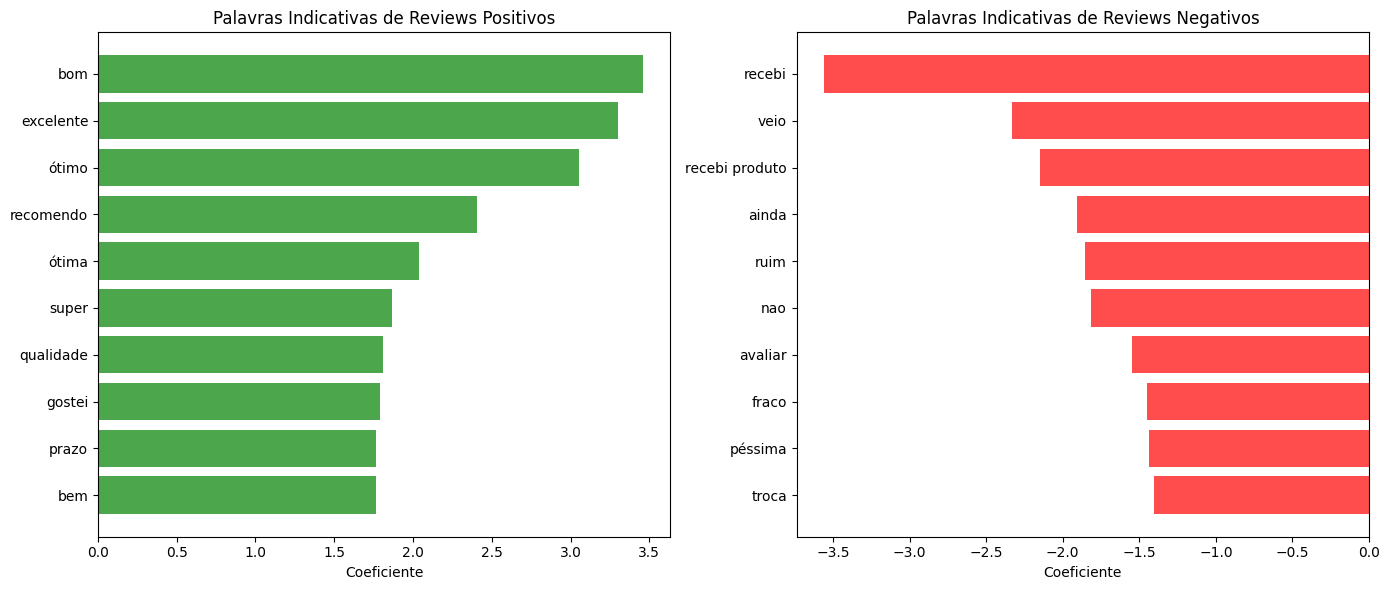

In [40]:
# Visualização das features mais importantes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positivas
palavras_pos = [p[0] for p in palavras_positivas]
coefs_pos = [p[1] for p in palavras_positivas]
axes[0].barh(palavras_pos[::-1], coefs_pos[::-1], color='green', alpha=0.7)
axes[0].set_xlabel('Coeficiente')
axes[0].set_title('Palavras Indicativas de Reviews Positivos')

# Negativas
palavras_neg = [p[0] for p in palavras_negativas]
coefs_neg = [p[1] for p in palavras_negativas]
axes[1].barh(palavras_neg[::-1], coefs_neg[::-1], color='red', alpha=0.7)
axes[1].set_xlabel('Coeficiente')
axes[1].set_title('Palavras Indicativas de Reviews Negativos')

plt.tight_layout()
plt.show()

---

## Verificação Final

Execute a célula abaixo para ver sua pontuação total:

In [41]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!

q8 results: All test cases passed!

---

**Certifique-se de que todos os testes passaram antes de submeter.**